In [ ]:
import numpy as np
from scipy.integrate import quad
from scipy.stats import norm, laplace, poisson
import yfinance as yf
import scipy.special
import statsmodels.api as sm
from math import factorial
import mpmath as mp
from scipy.fft import ifft, fftfreq, fftshift, ifftshift
from scipy.integrate import trapezoid
from pyexpat import model
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.signal import windows
from scipy.signal import savgol_filter
from matplotlib.gridspec import GridSpec


In [32]:
# ========================== Jump and waiting time distributions ==========================


def h(omega, sigma, model):
    """
    Jump distribution h(x|sigma) in the Fourier domain.
    Variable model selects the distribution type:
        - 'gaussian':    h(x|sigma) = (1/sqrt(2*pi*sigma^2)) * exp(-x^2 / (2*sigma^2))
        - 'laplace':     h(x|sigma) = (1/(sqrt(2)*sigma)) * exp(-sqrt(2)*|x|/sigma)
    """
    if model == 'gaussian':
        h = np.exp(-0.5*(sigma * omega)**2)
    elif model == 'laplace':
        h = 2/(2+(sigma*omega)**2)
    else:
        raise ValueError("Unsupported model type. Use 'gaussian' or 'laplace'.")
    return h

def psi(s, lam, model):
    """
    Waiting time distribution psi(t) in the Laplace domain.
    Variable model selects the distribution type:
        - 'exponential':     psi(t) = lambda * exp(-lambda*t) → psi(s) = lambda / (s + lambda)
    """
    if model == 'exponential':
        psi = 1/ (s + 1)
    else:
        raise ValueError("Unsupported model type. Use 'exponential'.")
    return psi

# ======================================= Kernel models =======================================
# This function is not currently being used. The OLS method is not very accurate when involving fat tails. It is left as the code can use it if
# the condition of "parameters_literature" is set to False. 

def parameters(sigma_real, f_model):
    """
    Estimate the parameters of the kernel from the data, using Ordinary Least Squares (OLS)
    """
    if f_model == 'ou':
        
        X = sigma_real[:-1]
        Y = sigma_real[1:]
        X = sm.add_constant(X)
        model = sm.OLS(Y, X).fit()
        c = model.params[0]

        phi = np.clip(model.params[1], 0.0001, 0.9999) # to ensure stationarity
        alpha = -np.log(phi)
        m = c/(1-phi)
        k = np.sqrt(2*alpha) * np.std(model.resid) / np.sqrt(1-phi**2)

        return alpha, m, k
    
    if f_model == 'expou':
        Ylog = np.log(sigma_real + 1e-8)
        X = Ylog[:-1]
        Z = Ylog[1:]
        X = sm.add_constant(X)
        model = sm.OLS(Z, X).fit()

        c = model.params[0]
        phi = np.clip(model.params[1], 0.0001, 0.9999) # to ensure stationarity
        alpha_expou = -np.log(phi)
        m_expou = c/(1-phi)
        k_expou = np.sqrt(2*alpha_expou) * np.std(model.resid) / np.sqrt(1-phi**2)

        return alpha_expou, m_expou, k_expou

    elif f_model == 'heston':
        # Parameter characteritzation should be done using typical variance space for CIR equation
        v_real = sigma_real**2   
        
        X = v_real[:-1]
        Y = v_real[1:]
        X = sm.add_constant(X)
        model = sm.OLS(Y, X).fit()
        
        c = model.params[0]
        phi = np.clip(model.params[1], 0.0001, 0.9999)
        kappa = -np.log(phi)
        theta = c / (1 - phi)
        
        resid = model.resid
        v_mean = np.mean(v_real)
        delta = np.sqrt(np.var(resid) / v_mean) 
    
        return kappa, theta, delta
    
    else:
        raise ValueError("Unsupported model type. Use 'ou', 'expou' or 'heston'.")


def f_n_ou(sigma, sigma_0, alpha, m, k, n, dt=1):
    """
    Transition kernel for OU.
    
    Variables: 
        sigma = current volatility
        sigma_0 = previous step volatility
    
    Parameters:
        sigma: current volatility
        sigma_0: initial volatility
        m: long-term mean
        k: volatility parameter
        alpha: mean reversion parameter
        n: number of jumps
        dt: time step
    """
    phi = np.exp(-alpha * n * dt)
    
    # Mean of the distribution
    M = m + phi * (sigma_0 - m)
    
    # Variance: V = k^2*(1-phi^2)/(2*alpha)
    V = (k**2) * (1 - phi**2) / (2 * alpha)
    
    if n == 0:
        # Delta function at sigma_0
        return 1.0 if abs(sigma - sigma_0) < 1e-10 else 0.0
    
    if V <= 0: # to ensure that no 1/0 appears
        return 0.0
    
    f = (1.0 / np.sqrt(2 * np.pi * V)) * np.exp(-(sigma - M)**2 / (2 * V))
    return f

def f_n_expou(sigma, sigma_0, alpha, m, k, n, dt=1):
    """ 
    Transition kernel for expOU model.
    
    Variables: 
        sigma = current volatility
        sigma_0 = previous step volatility

    Parameters:
        m = reverting mean
        k = strength of the noise
        alpha = speed of mean reversion
        t = time at which we want to evaluate the pdf
        t=0 = previous time step 
    """
    phi = np.exp(-alpha * n * dt)
    
    # Mean of the distribution
    M = m + phi * (np.log(sigma_0) - m)
    
    # Variance
    V = (k**2) * (1 - phi**2) / (2 * alpha)
    
    
    if n == 0:
        # Delta function at sigma_0
        return 1.0 if abs(sigma - sigma_0) < 1e-10 else 0.0
    
    f = (1.0 / np.sqrt(2 * np.pi * V)) * np.exp(-(np.log(sigma) - M)**2 / (2 * V))*(1/sigma)
    return f

def f_n_heston(sigma, sigma_0, kappa, theta, delta, n, dt=1):
    """
    Transition kernel for Heston model.

    Variables:
       sigma = current volatility
       sigma_0 = previous step volatility

    Parameters:
       kappa = speed of mean reversion
       theta = long-term mean volatility
       delta = volatility of volatility
       n = number of jumps
       dt = time step
    """
    if n == 0:
        # Delta function at sigma_0
        return 1.0 if abs(sigma - sigma_0) < 1e-10 else 0.0
    
    c   = (delta**2 * (1 - np.exp(-n*kappa*dt))) / (4*kappa)
    nu  = (2*kappa*theta) / (delta**2)
    z = sigma * sigma_0 * np.exp(-n*kappa*dt/2) / c

    # Use ive for numerical stability (ive = exp(-z)*I_nu)
    # so we add z back in the exponent manually
    f = (sigma / c) \
        * np.exp(-(sigma**2 + sigma_0**2 * np.exp(-n*kappa*dt)) / (2*c) + z) \
        * (sigma / (sigma_0 * np.exp(-n*kappa*dt/2))) ** (nu - 1) \
        * scipy.special.ive(nu - 1, z)
    return f

def kernel(sigma, sigma_0, rev_str, mean, noise, n, dt, model):
    """
    Transition kernel for the volatility process.
    Variable model selects the distribution type:
        - 'ou':         Ornstein-Uhlenbeck process      f_n_ou(sigma, sigma_0, alpha, m, k, n, dt=1)
        - 'expou':      Exponential OU process           f_n_expou(sigma, sigma_0, alpha, m, k, n, dt=1)
        - 'heston':     Heston model                    f_n_heston(sigma, sigma_0, kappa, theta, delta, n, dt=1)
    """
    if model == 'ou':
        return f_n_ou(sigma, sigma_0, rev_str, mean, noise, n, dt)
    elif model == 'expou':
        return f_n_expou(sigma, sigma_0, rev_str, mean, noise, n, dt)
    elif model == 'heston':
        return f_n_heston(sigma, sigma_0, rev_str, mean, noise, n, dt)
    else:
        raise ValueError("Unsupported model type. Use 'ou', 'expou' or 'heston'.")
    
# The number of jumps is determined by the waiting time distribution. Fixing a low N will cut the tails off, while a high N will increase the
# computational cost rapidly.

def choose_N_max(psi, t_max, target_tail=1e-4, N_min=10, N_cap=200):
    """
    The number of jumps determined by the waiting time distribution.
    """
    for N in range(N_min, N_cap+1):
        F_N=inverse_laplace_mpmath(lambda s, k=N+1: psi(s) ** k/s, t_max)
        if F_N < target_tail:
            return N
    return N_cap # if any N is enough to show the full tail's behaviour, return the cap we imposed



# ================================ Integral matrix computation ===========================================


def sigma_grid (model, rev_str, mean, noise, n_stds=10 ,n_grid=250):
    """
    A grid is built for the sigma values. Then, each position of the matrix will relate two diferent sigmas, allowing to compute f(sigma_n, sigma_n-1). 
    To build that, we will use the stationary versions of the kernels to delimit the grid bounds.
    """
    
    if model == 'ou':
        V_stat = noise**2 / (2 * rev_str) # stationary variance of sigma
        half_w = n_stds * np.sqrt(V_stat) # half of the width of the grid
        grid = np.linspace(mean - half_w, mean + half_w, n_grid)
        sigma_grid = grid 
    elif model == 'expou':
        V_stat = noise**2 / (2*rev_str) # Stationary variance of log(sigma)
        half_w = n_stds*np.sqrt(V_stat)
        grid = np.linspace(mean - half_w, mean + half_w, n_grid)
        sigma_grid = np.exp(grid) 
    elif model == 'heston':
        V_stat = mean * noise**2 / (2 * rev_str) # stationary variance of sigma
        half_w = mean + n_stds * np.sqrt(V_stat) 
        sigma_min = max(1e-3, 1e-3 * np.sqrt(half_w)) 
        sigma_max = np.sqrt(half_w)
        grid = np.linspace(sigma_min, sigma_max, n_grid)
        sigma_grid = grid
    else:
        raise ValueError("Unsupported model type. Use 'ou', 'expou' or 'heston'.")
    
    dgrid = grid[1]-grid[0]
    return sigma_grid, dgrid
 
def kernel_matrix (sigma_grid, dgrid, rev_str, mean, noise, dt, model, n=1):
    """
    The grid is filled with transition pdf for the specified model and the jump distribution
    """
    
    f=np.zeros((len(sigma_grid),len(sigma_grid)))
    for i in range(len(sigma_grid)):
        for j in range(len(sigma_grid)):
            f[i,j] = kernel(sigma_grid[i], sigma_grid[j], rev_str, mean, noise, n, dt, model)
    if model == 'expou':
        f *= sigma_grid[:, None]
    return f*dgrid

def k_step(k, f, H):
    """Apply the transfer operator once:  k_new = H .* (F @ k)."""
    return H * (f @ k)

# This function is not currently being used. Because of the exponential distributed waiting times ansatz, the inverse Laplace transform can
# be computed analytically. However, if "model_psi" is changed, this function will be used. 
def inverse_laplace_mpmath(P_s_func, t, method='talbot', degree=16):
    """
    Inverse Laplace using mpmath library, through method Talbot
    
    P_s_func: function in Laplace domain
    t: time to evaluate
    methods: 'talbot', 'dehoog', 'cohen', or 'stehfest'
            Talbot aproximates the value of the inverse Laplace transform  f(t), for fixed t, using the complex values of the Laplace transform F(s) 
            sampled on a suitable contour of the complex plane. This contour is built through hyperbolic sinus and cosinus, enveloping any singularity.
            It has high precision and is efficient for a wide range of functions, including those with singularities or slow decay (our case). 
            However, it can be computationally intensive for large t. (other models were tried with less success, such as gaver-stehfest)
    degree: accuracy parameter (higher = more accurate but slower)
    """
    if t <= 1e-8:
        return 0.0
    
    def P_s_mpmath(s):
        s_complex = complex(s)  # define the complex variable
        return P_s_func(s_complex)
        
    # Use mpmath's inverse Laplace
    result = mp.invertlaplace(P_s_mpmath, t, method=method, degree=degree)
        
    # Convert back to float
    return float(result.real)

In [33]:
# ========================= Model selection ========================

# We can choose between 'ou', 'expou', and 'heston' for the kernel, and 'gaussian' or 'laplace' for the jump distribution.
model_f = 'ou'
model_h = 'gaussian'
model_psi = 'exponential'

# To avoid loosing the phenomenology of the tails, we suppress the dicrac's delta 
suppress_n0 = False

lam = 100  # jumps/day. This value is chosen to be high enough to reflect a "fluid" market

# This parameter can be used to smooth the volatility process while preserving it's properties
window = 1  # n-day rolling volatility

# Time control:
time_range_long = True

# Parameters control:
parameters_literature = True 

# ==================== Data (DAILY units throughout) ====================
ticker = "^DJI" # Dow Jones Industrial Average
data = yf.download("^DJI", start="2024-01-01", end="2025-01-01")
prices = data["Close"].values.flatten()

# Daily log returns 
returns = np.diff(np.log(prices))


# If the window is grater than 1, the volatility is computed as the standard deviation of the returns in this window, smoothing the volatility. If this value
# is 1, then an alternative method is used, based on the method of moments, which takes the standard deviation from the returns through an estimating factor from the jump
# distribution:

if window == 1:
    # Method-of-moments:
    # Gaussian:  E[|r| / sigma] = sqrt(2/pi)  ->  sigma_hat = sqrt(pi/2) * |r|  
    # Laplace :  E[|r| / sigma] = 1/sqrt(2)   ->  sigma_hat = sqrt(2)    * |r|
    if model_h == 'gaussian':
        estimator_factor = np.sqrt(np.pi / 2)
    elif model_h == 'laplace':
        estimator_factor = np.sqrt(2)
    else:
        raise ValueError(f"Unknown model_h: {model_h}")
    sigma_real = estimator_factor * np.abs(returns)
else:
    nb = len(returns) // window
    sigma_daily = returns[:nb*window].reshape(nb, window).std(axis=1)  # one RV per block
    sigma_real = np.maximum(sigma_daily / np.sqrt(lam), 1e-6)

print(f"Daily sigma range : [{sigma_real.min():.4e}, {sigma_real.max():.4e}]")
print(f"Daily sigma mean  :  {sigma_real.mean():.4e}")
print(f"Daily sigma std   :  {sigma_real.std():.4e}")

# ======================== Parameter Estimation =========================
# Parameters can be either estimated from the data, through OLS, or taken from the literature. The data is daily, so the parameters have to be renormalized to be suitable
# for intraday timescales. This is done through the parameter lambda. 
if parameters_literature == False:
    rev_str, mean, noise = parameters(sigma_real, model_f)
    # renormalizing:
    rev_str = rev_str/lam
    mean    = mean/np.sqrt(252)/np.sqrt(lam)
    noise   = noise/lam

elif parameters_literature == True:
    # Volatility-kernel parameters from literature:
    if model_f == 'ou': 
        # J. Masoliver, M. Montero, J. Perelló and G. H. Weiss, "The continuous time random walk formalism in 
        # financial markets". Journal of Economic Behaviour and Organization {\bf 61}: 577-598 (2006).
        rev_str = 0.05/lam                                 
        mean    = 0.189 / np.sqrt(252)/ np.sqrt(lam)  # Need for 1/np.sqrt(252) as are in years in the paper
        noise   = 1.4e-3/np.sqrt(lam)                  
    elif model_f == 'expou':
            expou_literature = True # expOU parameters can be derived from the OU parameters, if false they will be derived.
            if expou_literature == True:
                # J. Perelló, "Market memory and fat tail consequences in option pricing on expOU stochastic volatility 
                # model". Physica A: Statistical Mechanics and its Applications {\bf 382}: 213-218 (2007).
                rev_str = 0.0018 /lam                                 
                mean    = 0.00141 / np.sqrt(252)/ np.sqrt(lam) # Need for 1/np.sqrt(252) as are in years in the paper
                noise   = 0.18 / np.sqrt(lam)   
            else:
                # or can be derived from the parameters of the OU model:
                rev_str = 0.05/lam                                  
                noise   = 1.4e-3/np.sqrt(lam)  
                mean    = (0.189 / np.sqrt(252)/ np.sqrt(lam))*np.exp(-noise**2/(4*rev_str)) 
                
    elif model_f == 'heston':
        # Adrian A. Dragulescu and Victor M. Yakovenko, ”Probability distribution of returns in the Heston model 
        # with stochastic volatility”. Quantitative Finance 2, 443 (2002).
        rev_str = 0.045 / lam                                 
        mean    = 0.0000862 / np.sqrt(lam)                  
        noise   = 0.00245 / np.sqrt(lam)              
    else:
        raise ValueError(f"Literature parameters still not defined for model_f={model_f}")
    
sigma_0 = sigma_real[0]/np.sqrt(lam) # renormalized to match the scaled parameters
dt = 1.0 # mean inter-jump time renormalized


print("=" * 60)
print(f"Estimated parameters for {model_f.upper()}  (DAILY units):")
print("=" * 60)
print(f"  rev_str  (unitless, as renorm.)            = {rev_str:.4f}                      {rev_str*lam} (days^-1) ")
print(f"  OU relaxation time  1/{rev_str}                = {1/rev_str:.2f} (unitless)         {1/(rev_str*lam)} (days) ")
print(f"  mean      (long-run sigma)                 = {mean:.4e} (volatility units)")
print(f"  noise     (vol of vol)                     = {noise:.4e} (unitless)             {noise*lam} (days^-1)")
print(f"  lambda    (jumps/day)                      = {lam}")
print(f"  sigma_0                                    = {sigma_0:.4e} (volatility units)")
print("=" * 60)

# ================================================= Grids =========================================================
# The grid is built using the stationary distribution of the kernels (to avoid arbitrary grid and cutting tails off)
sigma_grid_vals, dsigma = sigma_grid(model_f, rev_str, mean, noise, n_stds=10, n_grid=250)
n_grid = len(sigma_grid_vals)

# Time range is set. To capture the full relaxation process of the second order moment, the time max limit is set using the reversion strength parameter. There
# are two options: a long range and a short one (as the time is related to the number of jumps per day, with a very fluid market the computation takes longer)
if time_range_long==True: 
    t_min, t_max, N_t = 0.1, 13*(1/rev_str), 100 # up to 13 times the relaxation time
    print(f"max time", 5*(1/rev_str))
if time_range_long==False:
    t_min, t_max, N_t = 0.1, 2*(1/rev_str), 100 # up to 2 times the relaxation time
t_range = np.logspace(np.log10(t_min), np.log10(t_max), N_t) # log-spaced time range to capture both short and long timescales

# stationary variance, used to set grid bounds and plot the references of the tails.
sigma2_stat  = mean**2 + noise**2 / (2 * rev_str)     # stationary <sigma^2>
X2_max_est   =  t_max * sigma2_stat              # rough <X^2(t_max)>
x_max_target = 10.0 * np.sqrt(X2_max_est)             # ~10 std of headroom

# Building of the omega grid for the Fourier transform, which adapts considering the x target value. The difficulty here is to capture the tails of the distibution,
# while keeping a good resolution arround the center, where the changes are more abrupt. All of this, considering the computational cost.
N_omega = 2048
omega_max = np.pi * N_omega / (2.0 * x_max_target)
d_omega = (2 * omega_max) / N_omega
omega_range = (np.arange(N_omega) - N_omega // 2) * d_omega
assert omega_range[N_omega // 2] == 0.0
print(f"N_omega (adaptive) = {N_omega},  x_max_target = {x_max_target:.4e}")

# Number of jumps to consider in the sum (ideally should be infinite), given by psi distribution.                      
if model_psi == 'exponential':
    N_max = int(np.ceil(t_max + 6.0*np.sqrt(t_max))) #truncate 6 sigma above the mean (tail ~1e-9)
else:
    N_max = choose_N_max(lambda s: psi(s, lam, model_psi), t_max)
print(f"N_max (jump truncation up to t_max={t_max} (unitless) = {t_max/lam} days)  =  {N_max}")

# ============================================= Integral ==============================================

# Using the grid matrix of volatilities, the kernel matrix can be built.

F = kernel_matrix(sigma_grid_vals, dsigma, rev_str, mean, noise, dt, model_f)
F = F / F.sum(axis=0, keepdims=True) # normalize columns
print(f"F column sums: min={F.sum(axis=0).min():.4f}  max={F.sum(axis=0).max():.4f}  (both ~1)")

H = h(omega_range[None, :], sigma_grid_vals[:, None], model_h) # jump distribution in Fourier space

# First jump
g1 = np.array([kernel(s, sigma_0, rev_str, mean, noise, n=1, dt=dt, model=model_f)
               for s in sigma_grid_vals])
if model_f == 'expou':
    g1 = g1 * sigma_grid_vals
g1 = g1 / (g1.sum() * dsigma)   

J_matrix = np.zeros((N_max + 1, N_omega))
J_matrix[0, :] = 0.0 if suppress_n0 else 1.0

# The J matrix is computed. It is the discreteintegral of the kernel with the jump distribution in the Fourier space
g = H * g1[:, None]
J_matrix[1, :] = g.sum(axis=0) * dsigma
for n in range(2, N_max + 1):
    g = k_step(g, F, H)
    J_matrix[n, :] = g.sum(axis=0) * dsigma

mid = N_omega // 2
err = np.max(np.abs(J_matrix[1:, mid] - 1.0))
print(f"max |J_n(0) - 1| = {err:.2e}  (should be < 1e-3)")
assert err < 1e-3, "J_n(0)!=1 -- widen grid or check Jacobian" # Safe check through normalization

if model_psi == 'exponential': # if psi is exponential, we can directly compute the Laplace transform analytically
    P_omega_t = np.zeros((N_omega, N_t))
    n_arr = np.arange(N_max + 1)
    for j, t in enumerate(t_range):
        weights = poisson.pmf(n_arr, t)        # e^{-lam t}(lam t)^n / n!, computed stably
        P_omega_t[:, j] = J_matrix.T @ weights        # sum_n weight_n * J_n(omega) 
else: # if psi is not exponential, the inverse Laplace transform is computed through Talbot's method.
    P_omega_t = np.zeros((N_omega, N_t))
    print("Performing inverse Laplace transform (s -> t)...")
    for omega_idx in range(N_omega):
        if omega_idx % 100 == 0:
            print(f"  omega {omega_idx}/{N_omega}...")
        for j, t in enumerate(t_range):
            def P_s_func(s, i=omega_idx):
                ps = psi(s, lam, model_psi)
                Psi = (1 - ps) / s
                powers = ps ** np.arange(N_max + 1)
                return Psi * np.sum(powers * J_matrix[:, i])
            P_omega_t[omega_idx, j] = inverse_laplace_mpmath(P_s_func, t)

# The mass can be lost in the numerical integration, it has to be checked!
print("\n*** RAW MASS in omega-space (before renormalisation) ***")
print(f"   {'t (days)':>10} {'P_hat(0,t)':>14} {'expected':>14}")
for j in range(0, N_t, max(1, N_t // 8)):
    t = t_range[j]
    expected = (1 - np.exp(-lam * t)) if suppress_n0 else 1.0
    print(f"   {t:10.2f} {P_omega_t[mid, j]:14.6f} {expected:14.6f}")

# If the initial delta is not included, the distribution has to be normalised
if suppress_n0 == True:
    print("\nRenormalising so that integral P(x,t) dx = 1 at each t (conditional on >=1 jump) ...")
    for j in range(N_t):
        Z = P_omega_t[mid, j]
        if Z > 1e-12:
            P_omega_t[:, j] /= Z

[*********************100%***********************]  1 of 1 completed


Daily sigma range : [1.6905e-05, 4.3984e-02]
Daily sigma mean  :  6.7051e-03
Daily sigma std   :  5.9921e-03
Estimated parameters for OU  (DAILY units):
  rev_str  (unitless, as renorm.)            = 0.0005                      0.05 (days^-1) 
  OU relaxation time  1/0.0005                = 2000.00 (unitless)         20.0 (days) 
  mean      (long-run sigma)                 = 1.1906e-03 (volatility units)
  noise     (vol of vol)                     = 1.4000e-04 (unitless)             0.013999999999999999 (days^-1)
  lambda    (jumps/day)                      = 100
  sigma_0                                    = 9.5017e-04 (volatility units)
max time 10000.0
N_omega (adaptive) = 2048,  x_max_target = 7.3923e+00
N_max (jump truncation up to t_max=26000.0 (unitless) = 260.0 days)  =  26968
F column sums: min=1.0000  max=1.0000  (both ~1)
max |J_n(0) - 1| = 5.27e-13  (should be < 1e-3)

*** RAW MASS in omega-space (before renormalisation) ***
     t (days)     P_hat(0,t)       expected
   

In [34]:
# ========================== Inverse Fourier =========================
# The inverse Fourier is performed through FFT. 

print("Performing inverse Fourier transform (omega -> x)...")
# The gris is adapted for FFT to be applied and x is rescaled to be dimensionless through gamma
x_grid  = 2 * np.pi * fftfreq(N_omega, d_omega) 
x_grid  = fftshift(x_grid)
gamma   = np.sqrt(2) / sigma_0
x_tilde = gamma * x_grid

# When performing inverse Fourier, Gibbs rings can occur due to abrupt cuttofs in the signal. We will taper by smoothing the signal. This
# is done to solve the tail oscilatory behaviour.
taper = windows.tukey(N_omega, alpha=0.3) 

# Finally, the inverse Fourier is applied to the matrix in the omega space. The result is rescaled to be dimensionless through gamma.
P_x_t = np.zeros((N_omega, N_t))
for j in range(N_t):
    P_omega_tapered = P_omega_t[:, j] * taper
    P_omega_shifted = ifftshift(P_omega_tapered)
    P_x_shifted     = ifft(P_omega_shifted)
    P_x_t[:, j]     = fftshift(np.real(P_x_shifted)) * N_omega * d_omega / (2 * np.pi)
    P_x_t[:, j]     = np.maximum(0, P_x_t[:, j])
P_tilde = P_x_t / gamma

# x-space mass check (should match P_hat(0,t) above)
print("\n*** Mass in x-space (should be ~1 after renormalisation) ***")
for j in range(0, N_t, max(1, N_t // 8)):
    print(f"   t={t_range[j]:6.2f}   integral P(x,t) dx = "
          f"{trapezoid(P_x_t[:, j], x_grid):.6f}")

Performing inverse Fourier transform (omega -> x)...

*** Mass in x-space (should be ~1 after renormalisation) ***
   t=  0.10   integral P(x,t) dx = 1.369091
   t=  0.45   integral P(x,t) dx = 1.362552
   t=  2.05   integral P(x,t) dx = 1.333729
   t=  9.31   integral P(x,t) dx = 1.220264
   t= 42.21   integral P(x,t) dx = 1.012226
   t=191.34   integral P(x,t) dx = 1.000019
   t=867.29   integral P(x,t) dx = 1.000000
   t=3931.18   integral P(x,t) dx = 1.000000
   t=17819.00   integral P(x,t) dx = 1.000000


### Plotting of the propagator $P(\gamma x, \lambda t)/\gamma$

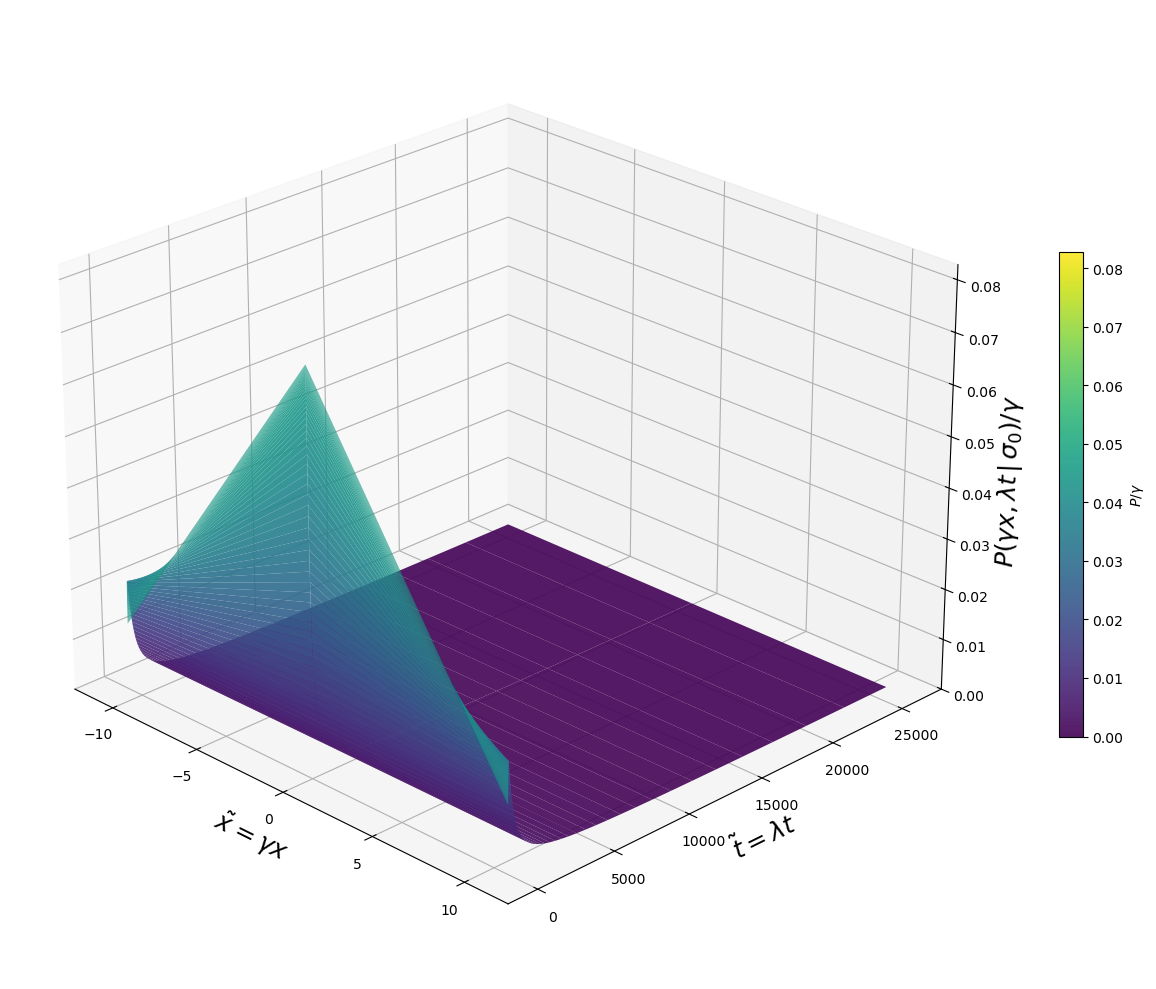

Maximum P_tilde = 0.0789  at  x_tilde = 0.00,  t = 0.10


In [35]:

#ATTENTION: The plotting of the return propagator is only realistic for low values of lambda. Otherwise, the truncation jumps, the grid bounds in both x and 
# omega, and the computational cost becomes prohibitive. The code is left as is for illustrative purposes, but for realistic values of lambda, it should be 
# somehow readapted to capture the complete phenomenology at both the center and the tails. The result should be similar to the one shown with this code at 
# lower values of lambda, but with a more pronounced tail and a sharper peak at the center.


# ============================== plot range ==============================
plot_full = True
x_plot_min, x_plot_max = -15, 15
x_mask_full = (x_tilde >= x_plot_min) & (x_tilde <= x_plot_max)
x_full = x_tilde[x_mask_full]
P_full = P_tilde[x_mask_full, :]
z_max = float(P_tilde.max()) * 1.05

if plot_full == True:

# ============================== Full-x 3D plot ==============================
    T_mesh, X_mesh = np.meshgrid(t_range, x_full)
    fig = plt.figure(figsize=(16, 10))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X_mesh, T_mesh, P_full, cmap='viridis', alpha=0.9, rcount=200, ccount=200, vmin=0, vmax=z_max)
    ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=18)
    ax.set_ylabel(r'$\tilde t = \lambda t$', fontsize=18)
    ax.set_zlabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=18)
    ax.set_zlim([0, z_max])
    plt.colorbar(surf, shrink=0.5, label=r'$P/\gamma$')
    ax.view_init(elev=25, azim=-45)
    plt.tight_layout()
    plt.savefig(f'P_f({model_f})_h({model_h})_full.png', dpi=200, bbox_inches='tight')
    plt.show()

    max_idx = np.unravel_index(np.argmax(P_full), P_full.shape)
    print(f"Maximum P_tilde = {P_full[max_idx]:.4f}  at  "f"x_tilde = {x_full[max_idx[0]]:.2f},  t = {t_range[max_idx[1]]:.2f}")

elif plot_full == False:

# ============================ Positive-x 3D plot ============================
    x_min = 0
    x_max = 8
    # The initial delta can be surpressed from the plot as seen in other works, to better capture the tail phenomenology
    if suppress_n0 == True:
        x_mask_pos = (x_tilde > x_min) & (x_tilde <= x_max) 
    else:
        x_mask_pos = (x_tilde >= x_min) & (x_tilde <= x_max)
    x_pos = x_tilde[x_mask_pos]
    P_pos = P_tilde[x_mask_pos, :]

    T_mesh, X_mesh = np.meshgrid(t_range, x_pos)
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X_mesh, T_mesh, P_pos, cmap='viridis', alpha=0.9,rcount=200, ccount=200,vmin=0, vmax=z_max)              
    ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=18)
    ax.set_ylabel(r'$\tilde t = \lambda t$', fontsize=18)
    ax.set_zlabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=18)
    ax.set_zlim([0, z_max])                                  
    plt.colorbar(surf, shrink=0.5, label=r'$P/\gamma$')
    ax.view_init(elev=25, azim=-45)
    plt.tight_layout()
    #plt.savefig(f'P_f({model_f})_h({model_h})_positive.png', dpi=200, bbox_inches='tight')
    plt.show()



### Result Analysis

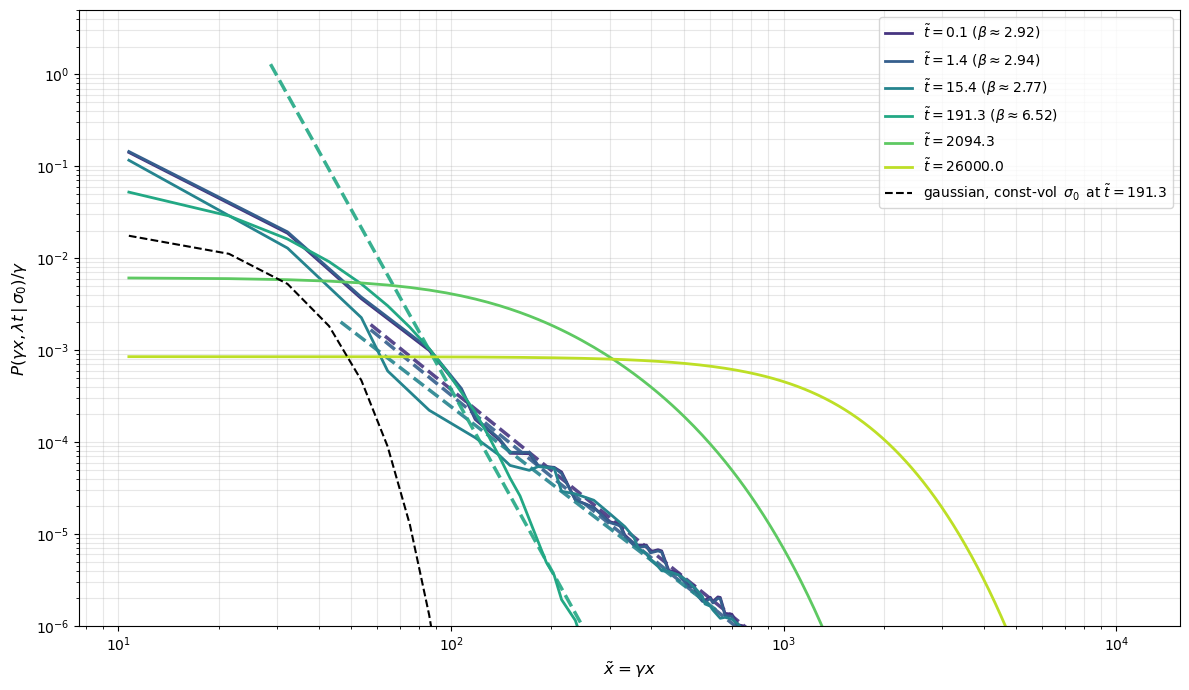

In [36]:
#========================================== Tail plotting ============================================

# Fit only the first FIT_N_CURVES to compute the power-law exponent. For the given parameters, tails given later than the fourth curve are gaussian
FIT_N_CURVES = 4


# To plot, we take 6 different times (the number of curves plotted). For the parameters chosen, 6 is enough to capture the features.
t_indices  = np.linspace(2, N_t - 1, 6, dtype=int)
times      = t_range[t_indices]
colors     = plt.cm.viridis(np.linspace(0.15, 0.9, len(t_indices)))

# The plot will be logarithmic to see the tails in detail, therefore only positive x must be considered.
x_pos_mask = x_tilde > 0
x_pos      = x_tilde[x_pos_mask]

fig, ax = plt.subplots(figsize=(12, 7))

# computing of the tails at each time, through a fit in a window adapted to each curve through its standard deviation.
for k, t_idx in enumerate(t_indices):
    P = P_tilde[x_pos_mask, t_idx].copy()
    P /= trapezoid(P, x_pos)
    mean_x = trapezoid(x_pos * P, x_pos)
    var_x  = trapezoid((x_pos - mean_x) ** 2 * P, x_pos)
    if k == len(t_indices) // 2:       
        var_for_ref = var_x    
    nz = P > 1e-12
    xx, pp = x_pos[nz], P[nz]
    logP_smooth = savgol_filter(np.log(pp), window_length=15, polyorder=3)

    # power-law fit only for the first FIT_N_CURVES curves 
    if k < FIT_N_CURVES:
        std_x = np.sqrt(var_x)
        fit_mask = (xx >= 4*std_x) & (xx <= 20.0*std_x) #control of the fit window 
        if fit_mask.sum() >= 3:
            slope = np.polyfit(np.log(xx[fit_mask]),logP_smooth[fit_mask], 1)[0]
            beta = -slope
            lbl = fr'$\tilde t={times[k]:.1f}$ ($\beta\approx{beta:.2f}$)'

            # draw the fitted line across the fit window
            x_line = np.array([xx[fit_mask][0]/3, xx[fit_mask][-1]])
            i_mid = fit_mask.sum() // 2
            anchor_x = xx[fit_mask][i_mid]
            anchor_y = np.exp(logP_smooth[fit_mask][i_mid])
            y_line = anchor_y * (x_line / anchor_x) ** slope
            ax.loglog(x_line, y_line, color=colors[k], ls='--', lw=2.5, alpha=0.9)
        else:
            lbl = fr'$\tilde t={times[k]:.1f}$'
    else:
        lbl = fr'$\tilde t={times[k]:.1f}$ '

    ax.loglog(xx, np.exp(logP_smooth), color=colors[k], lw=2, label=lbl)

# ============================ Gaussian reference ===============================
# Time reference
tau_ref = times[len(t_indices)//2]  

# variance reference
if model_f == 'heston':
    sigma2_stat = mean
elif model_f == 'expou':
    sigma2_stat = np.exp(2*mean + noise**2/rev_str)
else:  # 'ou'
    sigma2_stat = mean**2 + noise**2/(2*rev_str)
sigma_stat = np.sqrt(sigma2_stat)

# Gaussian reference. Can be done either with the initial volatility, or the mean colatility after termalitzation:
REF_MODE = 'sigma_0'   # 'sigma_0' or 'sigma_stat'

if REF_MODE == 'sigma_0':
    ref_std_tilde = np.sqrt(2.0 * tau_ref)
    ref_subscript = r'\sigma_0'
elif REF_MODE == 'sigma_stat':
    ref_std_tilde = np.sqrt(2.0 * tau_ref) * sigma_stat / sigma_0
    ref_subscript = r'\sigma_\infty'

if model_h == 'gaussian':
    ref = norm.pdf(x_pos, loc=0, scale=ref_std_tilde)
    ref_label = fr'gaussian, const-vol $\,{ref_subscript}\,$ at $\tilde t={tau_ref:.1f}$'
elif model_h == 'laplace':
    ref = laplace.pdf(x_pos, loc=0, scale=ref_std_tilde/np.sqrt(2))
    ref_label = fr'laplace, const-vol $\,{ref_subscript}\,$ at $\tilde t={tau_ref:.1f}$'

ax.loglog(x_pos[ref > 1e-12], ref[ref > 1e-12], 'k--', lw=1.5, label=ref_label)
ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=12)
ax.set_ylabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=12)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim([1e-6, 5])
plt.tight_layout()
plt.show()


Slopes (linear fits on the VIEW window):
  early:  alpha = 1.0005 ± 0.0000
  middle:     alpha = 1.639 ± 0.007
  late:   alpha = 1.099 ± 0.004


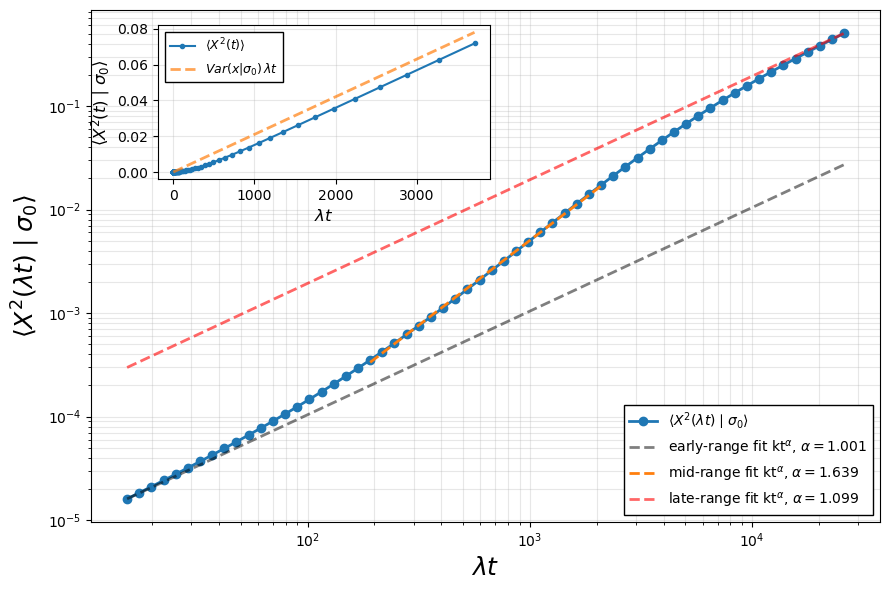


Effective exponent  alpha(lambda t) = d log<X^2>/d log lambda t   (1 = normal):
  lambda t =    0.11    alpha ~ 1.001
  lambda t =    2.33    alpha ~ 1.011
  lambda t =   54.30    alpha ~ 1.205
  lambda t = 1265.47    alpha ~ 1.685
  lambda t = 26000.00    alpha ~ 1.092


In [37]:
# ==================== <X^2(tilde_t)|sigma_0> — diffusive behaviour ====================

# Using the same grid and kernel matrix, the second order moment can be computed. See the work for further understandment.

# Computation of the integral of the variance with the kernel.
V_grid = sigma_grid_vals**2
E_V_j  = np.zeros(N_max + 1)
fj     = g1.copy()
E_V_j[1] = np.sum(V_grid * fj) * dsigma
for j in range(2, N_max + 1):
    fj = F @ fj
    E_V_j[j] = np.sum(V_grid * fj) * dsigma

# Sum of the integral from j=1 to n
S_k = np.cumsum(E_V_j[1:])

# Involvement of the Poisson distribution (due exponential distribution inverse transform) through the sum of the jumps
X2_t = np.zeros(N_t)
k_vals = np.arange(1, N_max + 1)
for idx, tilde_t in enumerate(t_range): # tilde_t = lambda t
    pk = poisson.pmf(k_vals, tilde_t) 
    X2_t[idx] = np.sum(pk * S_k)

# ========================================== knobs ========================================
# To avoid plotting the full range and focussing on the relaxation timescale:

time_focus = 'late'      # 'full' or 'late'   (default: 'late' for large lam)
LATE_FRAC = 0.6          # in 'late' mode, fraction of log-tilde_t range to KEEP from the right

# view window
log_t_arr = np.log10(t_range)
if time_focus == 'late':
    cut = log_t_arr[-1] - LATE_FRAC * (log_t_arr[-1] - log_t_arr[0])
    view = log_t_arr >= cut
    title_suffix = f" — late-time zoom (rightmost {int(100*LATE_FRAC)}% of lambda t)"
else:
    view = np.ones_like(t_range, dtype=bool)
    title_suffix = ""
 
t_view  = t_range[view]
X2_view = X2_t[view]

# Slope plotting, fitting, and error estimation: 
n_view = len(t_view)
mid_lo, mid_hi = n_view // 3, (2 * n_view) // 3
t_mid_seg = t_view[mid_lo:mid_hi]
log_t_mid  = np.log(t_view[mid_lo:mid_hi])
log_X2_mid = np.log(X2_view[mid_lo:mid_hi])
slope_mid, intercept_mid = np.polyfit(log_t_mid, log_X2_mid, 1)

# Defined here as only used in this piece of the code
def _fit_slope_err(seg_t, seg_X2):
    """log-log slope and its 1-sigma standard error."""
    x, y = np.log(np.asarray(seg_t)), np.log(np.asarray(seg_X2))
    if len(x) < 3:
        return np.polyfit(x, y, 1)[0], np.nan
    coef, cov = np.polyfit(x, y, 1, cov=True)
    return coef[0], float(np.sqrt(cov[0, 0]))

# Fitting of the superdiffusive fit
coef_mid, cov_mid = np.polyfit(log_t_mid, log_X2_mid, 1, cov=True)
slope_mid, intercept_mid = coef_mid
e_mid = float(np.sqrt(cov_mid[0, 0]))

s_early, e_early = _fit_slope_err(t_range[:3], X2_t[:3])
s_late,  e_late  = _fit_slope_err(t_view[-3:], X2_view[-3:])
print("\nSlopes (linear fits on the VIEW window):")
print(f"  early:  alpha = {s_early:.4f} ± {e_early:.4f}")
print(f"  middle:     alpha = {slope_mid:.3f} ± {e_mid:.3f}")
print(f"  late:   alpha = {s_late:.3f} ± {e_late:.3f}")



# Log-log main plot
fig, ax_main = plt.subplots(figsize=(9, 6))

ax_main.loglog(t_view, X2_view, 'o-', lw=2,
               label=r'$\langle X^2(\lambda t)\mid\sigma_0\rangle$')
ax_main.loglog(t_view, X2_view[0] * (t_view/t_view[0]), 'k--', alpha=0.5, lw=2,
               label=fr'early-range fit kt$ ^\alpha$, $\alpha={s_early:.3f}$')

ax_main.set_xlabel(r'$\lambda t = \lambda t$', fontsize=12)
ax_main.set_ylabel(r'$\langle X^2(\lambda t)\mid \sigma_0\rangle$', fontsize=12)

y_mid_seg = np.exp(intercept_mid) * t_mid_seg**slope_mid
ax_main.loglog(t_mid_seg, y_mid_seg, color='tab:orange', ls='--', lw=2,
               label=fr'mid-range fit kt$ ^\alpha$, $\alpha={slope_mid:.3f}$')

ax_main.loglog(t_view, X2_view[-1] * (t_view/t_view[-1]), 'r--', alpha=0.6, lw=2,
               label=fr'late-range fit kt$ ^\alpha$, $\alpha={s_late:.3f}$')
 
ax_main.set_xlabel(r'$ \lambda t$', fontsize=18)
ax_main.set_ylabel(r'$\langle X^2(\lambda t)\mid \sigma_0\rangle$', fontsize=18)

ax_main.legend(loc='lower right', fontsize=10, frameon=True, framealpha=1,
               edgecolor='black', facecolor='white', fancybox=False)
ax_main.grid(True, alpha=0.3, which='both')



# Linear inset
ax_in = ax_main.inset_axes([0.085, 0.67, 0.42, 0.30])
ax_in.plot(t_range/7, X2_t/7, 'o-', lw=1.5, ms=3,
           label=r'$\langle X^2(t)\rangle$')
ax_in.plot(t_range/7, (mean**2 + noise**2/(2*rev_str)) * t_range/7, '--', lw=2, alpha=0.7,label=r'$Var(x|\sigma_0)\,\lambda t$')

ax_in.set_xlabel(r'$\lambda t$', fontsize=12)
ax_in.set_ylabel(r'$\langle X^2(t)\mid \sigma_0 \rangle$', fontsize=12)
ax_in.tick_params(labelsize=10)
ax_in.legend(fontsize=9, loc='best', frameon=True, framealpha=1,
               edgecolor='black', facecolor='white', fancybox=False)
ax_in.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Exponent printed for further detail
log_t  = np.log(t_range)
log_X2 = np.log(X2_t)
alpha_eff = np.gradient(log_X2, log_t)
print("\nEffective exponent  alpha(lambda t) = d log<X^2>/d log lambda t   (1 = normal):")
for idx in [1, N_t//4, N_t//2, 3*N_t//4 , N_t-1]:
    print(f"  lambda t = {t_range[idx]:7.2f}    alpha ~ {alpha_eff[idx]:.3f}")


## Extra graphic representations

Extra graphic configurations for a better ilustration on the work submited. 
- In the first cell, the tail plot at six time horizons is repeated, but 3 more plots are added varying one of the model's parameters each. To do so, as the full integral and transforms have to be recomputed, the code seen until now is condensed in a single cell.
- In the second cell, the same plot is repeated, now adding an extra plot, which corresponds to the tail plot without the logarithmic scale and centered in zero.

[regime=empirical]  baseline rev_str = 5.000e-04   kappa*tau_focus = 0.096   (1/kappa = 2000.0, tau_focus = 191.3)


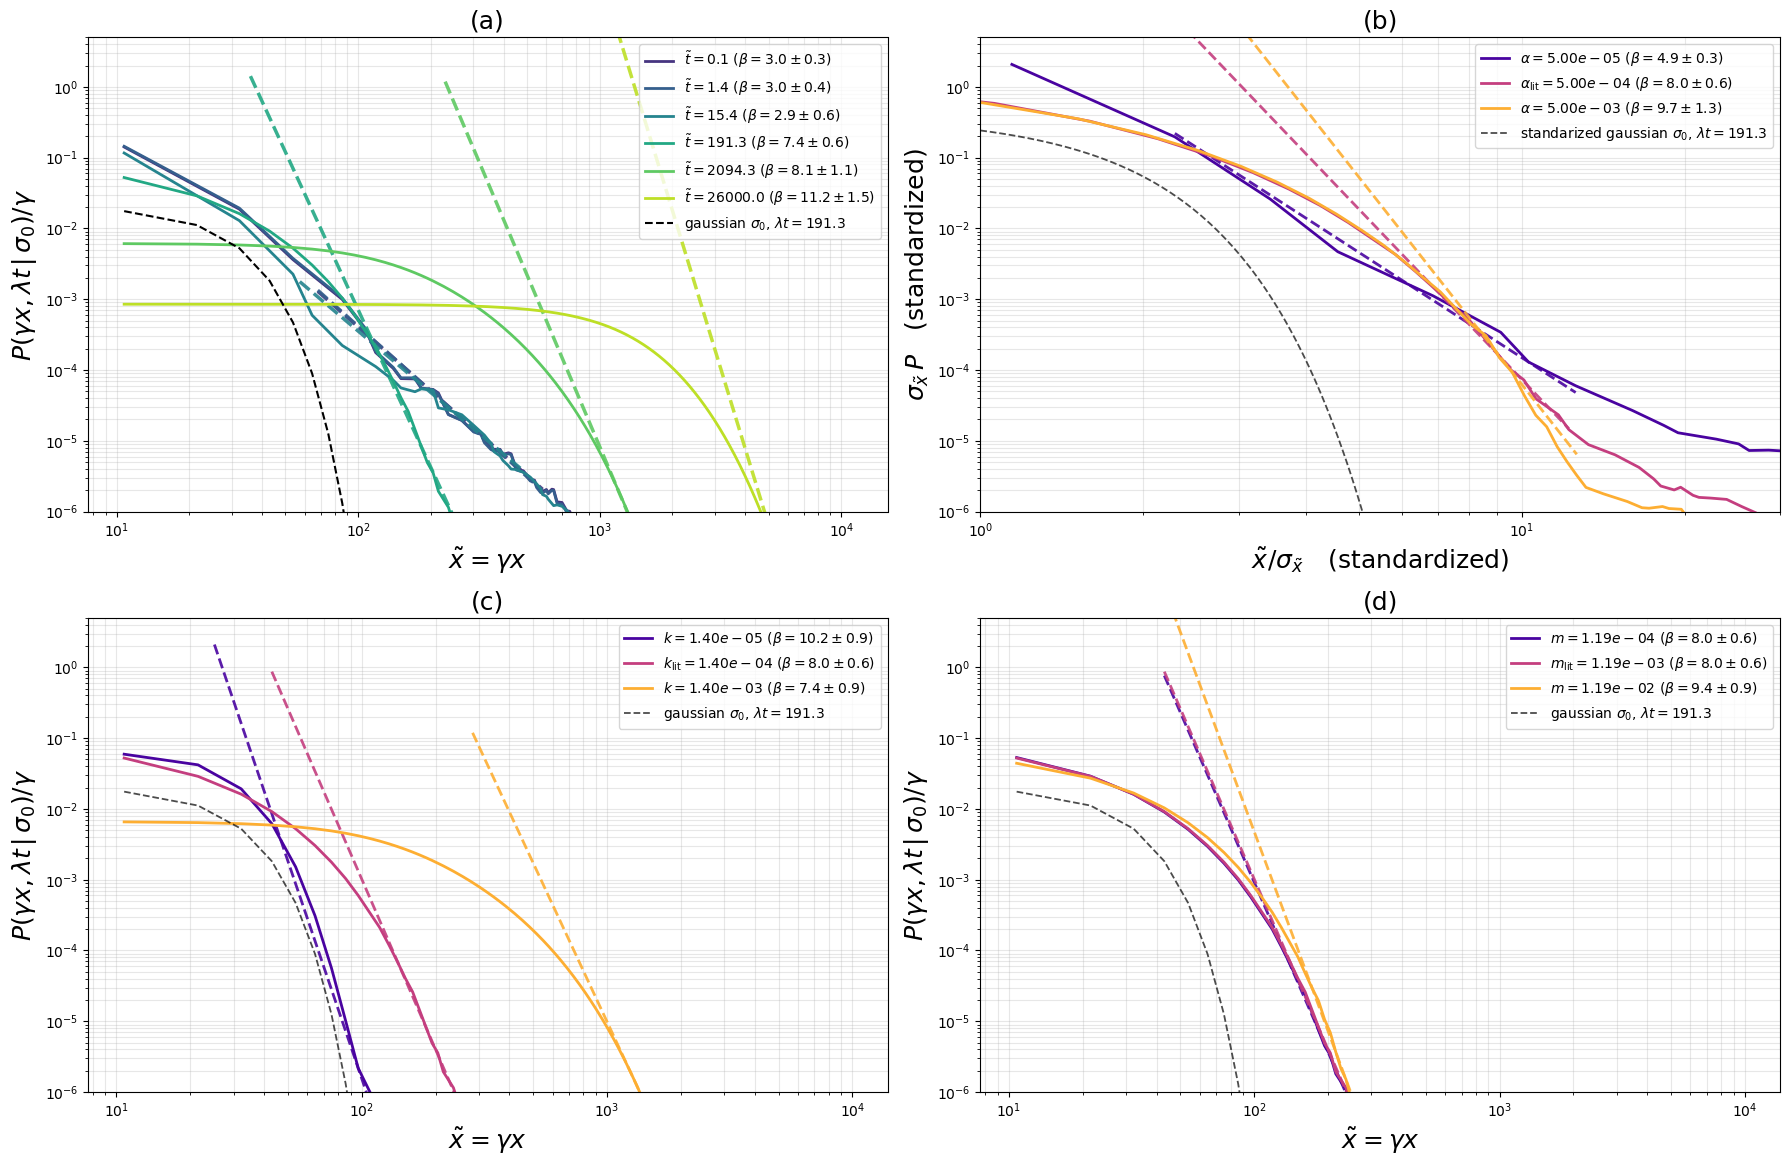

In [38]:

# We reuse much of the code from cells 2 and 3:
BASE_NOMEGA = N_omega
BASE_XMAX   = x_max_target
BASE_TMAX   = t_max
BASE_NGRID  = len(sigma_grid_vals)
N_t_base    = N_t

# ---- knobs ----
FIT_N_CURVES  = 6                  
FOCUS_K       = FIT_N_CURVES - 3   
SWEEP_FACTORS = [0.1, 1.0, 10.0]   # parameter multipliers to vary noise & mean (having a multiplier = 1 allows as to have a reference of the original fit)
REVSTR_FACTORS = [0.1, 1.0, 10.0]  # parameter multipliers to vary reversion strenght (having it independent from the rest of parameters could allow us to
                                   # test the effect of super-reversing the volatility, or slow down the reverse to see clustering)
FIT_LO, FIT_HI = 8.0, 20.0         # power-law fit window
FIT_LO_RANGE  = (4.0, 8.0)         # vary the window's lower edge over this range (in std)
FIT_HI_RANGE  = (10.0, 16.0)       # vary the window's upper edge over this range (in std)
N_FIT_WINDOWS = 5                  # grid points per edge 

# REGIME can be set to try to adjust the timescales at which the fit is performed, so that the effect of parameter variations can be "exagerated". Better set it 
# to empirical to remain loyal to the original fit and data.
REGIME            = 'empirical'      # 'empirical' or 'explore'
EXPLORE_KAPPA_TAU = 0.7            # target value of kappa * tau_focus in explore mode


def compute_P_tilde(rev_str_, mean_, noise_, t_max=None, N_t=N_t_base,
                    N_omega=BASE_NOMEGA, n_stds=10, n_grid=BASE_NGRID,
                    Nmax_cap=None, x_max_target=None):
    """
    Re-runs cells 2 + 3 for a given (rev_str, mean, noise) and return (x_tilde, t_range, P_tilde).
    """

    # cell 2: grid 
    sigma_grid_vals, dsigma = sigma_grid(model_f, rev_str_, mean_, noise_,
                                         n_stds=n_stds, n_grid=n_grid)
    t_min = 0.1
    if t_max is None:
        t_max = 13 * (1.0 / rev_str_)
    t_range = np.logspace(np.log10(t_min), np.log10(t_max), N_t)

    sigma2_stat = mean_**2 + noise_**2 / (2 * rev_str_)
    if x_max_target is None:                       # your adaptive formula
        x_max_target = 10.0 * np.sqrt(t_max * sigma2_stat)
    omega_max   = np.pi * N_omega / (2.0 * x_max_target)
    d_omega     = (2 * omega_max) / N_omega
    omega_range = (np.arange(N_omega) - N_omega // 2) * d_omega

    if model_psi == 'exponential':
        N_max = int(np.ceil(t_max + 6.0 * np.sqrt(t_max)))
    else:
        N_max = choose_N_max(lambda s: psi(s, lam, model_psi), t_max)
    if Nmax_cap is not None:
        N_max = min(N_max, int(Nmax_cap))

    # cell 3: kernell and the integral in Fourier space
    F = kernel_matrix(sigma_grid_vals, dsigma, rev_str_, mean_, noise_, dt, model_f)
    F = F / F.sum(axis=0, keepdims=True)

    H = h(omega_range[None, :], sigma_grid_vals[:, None], model_h)

    g1 = np.array([kernel(s, sigma_0, rev_str_, mean_, noise_, n=1, dt=dt, model=model_f)
                   for s in sigma_grid_vals])
    if model_f == 'expou':
        g1 = g1 * sigma_grid_vals
    g1 = g1 / (g1.sum() * dsigma)

    J_matrix = np.zeros((N_max + 1, N_omega))
    J_matrix[0, :] = 0.0 if suppress_n0 else 1.0
    g = H * g1[:, None]
    J_matrix[1, :] = g.sum(axis=0) * dsigma
    for n in range(2, N_max + 1):
        g = k_step(g, F, H)
        J_matrix[n, :] = g.sum(axis=0) * dsigma

    mid = N_omega // 2
    err = np.max(np.abs(J_matrix[1:, mid] - 1.0))
    if err > 1e-3:
        print(f"  [warn] max|J_n(0)-1| = {err:.2e}  "
              f"(rev_str={rev_str_:.3e}, mean={mean_:.3e}, noise={noise_:.3e})")

    # Cell 3: Laplace transform, mantaining the Poisson structure if psi is exponential, and Talbot's otherwise
    if model_psi == 'exponential':
        P_omega_t = np.zeros((N_omega, N_t))
        n_arr = np.arange(N_max + 1)
        for j, t in enumerate(t_range):
            P_omega_t[:, j] = J_matrix.T @ poisson.pmf(n_arr, t)
    else:
        P_omega_t = np.zeros((N_omega, N_t))
        for omega_idx in range(N_omega):
            for j, t in enumerate(t_range):
                def P_s_func(s, i=omega_idx):
                    ps = psi(s, lam, model_psi)
                    Psi = (1 - ps) / s
                    powers = ps ** np.arange(N_max + 1)
                    return Psi * np.sum(powers * J_matrix[:, i])
                P_omega_t[omega_idx, j] = inverse_laplace_mpmath(P_s_func, t)

    if suppress_n0:
        for j in range(N_t):
            Z = P_omega_t[mid, j]
            if Z > 1e-12:
                P_omega_t[:, j] /= Z

    # Cell 3: Fourier transform
    x_grid  = fftshift(2 * np.pi * fftfreq(N_omega, d_omega))
    gamma   = np.sqrt(2) / sigma_0
    x_tilde = gamma * x_grid
    taper   = windows.tukey(N_omega, alpha=0.3)

    P_x_t = np.zeros((N_omega, N_t))
    for j in range(N_t):
        P_x = fftshift(np.real(ifft(ifftshift(P_omega_t[:, j] * taper))))
        P_x_t[:, j] = np.maximum(0, P_x * N_omega * d_omega / (2 * np.pi))

    return x_tilde, t_range, P_x_t / gamma


def tail_profile(P_col, x_tilde):
    """Normalise the positive-x slice, smooth log P, return (xx, logP_smooth, var_x)."""
    m = x_tilde > 0
    x_pos = x_tilde[m]
    P = P_col[m].copy()
    Z = trapezoid(P, x_pos)
    if Z <= 0:
        return None
    P /= Z
    mean_x = trapezoid(x_pos * P, x_pos)
    var_x  = trapezoid((x_pos - mean_x) ** 2 * P, x_pos)
    nz = P > 1e-12
    xx, pp = x_pos[nz], P[nz]
    if len(xx) < 7:
        return None
    wl = min(15, len(xx) if len(xx) % 2 == 1 else len(xx) - 1)   # guard savgol window
    logP_smooth = savgol_filter(np.log(pp), window_length=wl, polyorder=min(3, wl - 1))
    return xx, logP_smooth, var_x


def powerlaw_fit(xx, logP_smooth, var_x, lo=FIT_LO, hi=FIT_HI):
    """Straight-line log-log fit on [lo*std, hi*std], return (beta, slope, x_line, y_line)"""
    std_x = np.sqrt(var_x)
    fit_mask = (xx >= lo * std_x) & (xx <= hi * std_x)
    if fit_mask.sum() < 3:
        return None
    slope = np.polyfit(np.log(xx[fit_mask]), logP_smooth[fit_mask], 1)[0]    # OLS method used.
    x_line = np.array([xx[fit_mask][0] / 3, xx[fit_mask][-1]])
    i_mid = fit_mask.sum() // 2
    anchor_x = xx[fit_mask][i_mid]
    anchor_y = np.exp(logP_smooth[fit_mask][i_mid])
    y_line = anchor_y * (x_line / anchor_x) ** slope
    return -slope, slope, x_line, y_line


def beta_with_error(xx, logP_smooth, var_x, lo_range=FIT_LO_RANGE, hi_range=FIT_HI_RANGE, n=N_FIT_WINDOWS):
    """ Estimates the power-law exponent and its error"""
    std_x = np.sqrt(var_x)
    los = np.linspace(lo_range[0], lo_range[1], n)
    his = np.linspace(hi_range[0], hi_range[1], n)
    betas, var_within = [], []
    for lo in los:
        for hi in his:
            if hi <= lo + 2.0:
                continue
            m = (xx >= lo * std_x) & (xx <= hi * std_x)
            if m.sum() < 5:
                continue
            X, Y = np.log(xx[m]), logP_smooth[m]
            coef, cov = np.polyfit(X, Y, 1, cov=True)
            betas.append(-coef[0])
            var_within.append(cov[0, 0])
    if not betas:
        return None
    betas = np.asarray(betas)
    between = np.var(betas, ddof=1) if len(betas) > 1 else 0.0
    within  = np.mean(var_within)
    return np.sqrt(between + within), float(betas.min()), float(betas.max()), len(betas)


# ============================== Plotting ==============================
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ---- focus tau = the last fat-tailed curve from panel (a) ----
t_indices = np.linspace(2, N_t - 1, 6, dtype=int)
times     = t_range[t_indices]
tau_focus = times[FOCUS_K]
NMAX_CAP  = int(np.ceil(tau_focus + 12.0 * np.sqrt(tau_focus) + 30))   # exact at tau_focus, fast
x_pos     = x_tilde[x_tilde > 0]

# Panel (a): Plot in cell 6
ax = axes[0, 0]
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(t_indices)))
x_pos_mask = x_tilde > 0

for k, t_idx in enumerate(t_indices):
    P = P_tilde[x_pos_mask, t_idx].copy()
    P /= trapezoid(P, x_pos)
    mean_x = trapezoid(x_pos * P, x_pos)
    var_x  = trapezoid((x_pos - mean_x) ** 2 * P, x_pos)
    if k == len(t_indices) // 2:
        var_for_ref = var_x
    nz = P > 1e-12
    xx, pp = x_pos[nz], P[nz]
    logP_smooth = savgol_filter(np.log(pp), window_length=15, polyorder=3)

    if k < FIT_N_CURVES:
        std_x = np.sqrt(var_x)
        fit_mask = (xx >= 5 * std_x) & (xx <= 15.0 * std_x) # controls how many points are used for the a) straight lines fit
        if fit_mask.sum() >= 3:
            slope = np.polyfit(np.log(xx[fit_mask]), logP_smooth[fit_mask], 1)[0]
            beta = -slope
            err = beta_with_error(xx, logP_smooth, var_x)
            if err is not None:
                beta_err, _, _, _ = err
                lbl = fr'$\tilde t={times[k]:.1f}$ ($\beta={beta:.1f}\pm{beta_err:.1f}$)'
            else:
                lbl = fr'$\tilde t={times[k]:.1f}$ ($\beta\approx{beta:.2f}$)'
            x_line = np.array([xx[fit_mask][0] / 3, xx[fit_mask][-1]])
            i_mid = fit_mask.sum() // 2
            anchor_x = xx[fit_mask][i_mid]
            anchor_y = np.exp(logP_smooth[fit_mask][i_mid])
            y_line = anchor_y * (x_line / anchor_x) ** slope
            ax.loglog(x_line, y_line, color=colors[k], ls='--', lw=2.5, alpha=0.9)
        else:
            lbl = fr'$\tilde t={times[k]:.1f}$'
    else:
        lbl = fr'$\tilde t={times[k]:.1f}$ '

    ax.loglog(xx, np.exp(logP_smooth), color=colors[k], lw=2, label=lbl)

ref_std = np.sqrt(var_for_ref) if 'var_for_ref' in dir() else np.sqrt(2)
tau_ref = times[len(t_indices) // 2]

if model_f == 'heston':
    sigma2_stat = mean
elif model_f == 'expou':
    sigma2_stat = np.exp(2 * mean + noise**2 / rev_str)
else:
    sigma2_stat = mean**2 + noise**2 / (2 * rev_str)
sigma_stat = np.sqrt(sigma2_stat)

REF_MODE = 'sigma_0'
if REF_MODE == 'sigma_0':
    ref_std_tilde = np.sqrt(2.0 * tau_ref)
    ref_subscript = r'\sigma_0'
elif REF_MODE == 'sigma_stat':
    ref_std_tilde = np.sqrt(2.0 * tau_ref) * sigma_stat / sigma_0
    if model_f == 'ou' or model_f == 'expou':
        ref_subscript = r'\sigma_\infty'
    elif model_f == 'heston':
        ref_subscript = r'\sqrt{\theta}'

if model_h == 'gaussian':
    ref = norm.pdf(x_pos, loc=0, scale=ref_std_tilde)
    ref_label = fr'gaussian $\sigma_0$, $\lambda t={tau_ref:.1f}$'
elif model_h == 'laplace':
    ref = laplace.pdf(x_pos, loc=0, scale=ref_std_tilde / np.sqrt(2))
    ref_label = fr'laplace, $\sigma_0$, $\lambda t={tau_ref:.1f}$'

ax.loglog(x_pos[ref > 1e-12], ref[ref > 1e-12], 'k--', lw=1.5, label=ref_label)
ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=18)
ax.set_ylabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=18)
ax.legend(fontsize=10, loc='upper right')
ax.grid(True, which='both', alpha=0.3)
ax.set_ylim([1e-6, 5])
ax.set_title(r'(a)', fontsize=18)


# To be ignored if we keep with the original fit and timescales
if REGIME == 'explore':
    base_rev = EXPLORE_KAPPA_TAU / tau_focus   # so kappa*tau_focus ~ EXPLORE_KAPPA_TAU
else:
    base_rev = rev_str                          # your fitted value
kappa_tau = base_rev * tau_focus
print(f"[regime={REGIME}]  baseline rev_str = {base_rev:.3e}   "f"kappa*tau_focus = {kappa_tau:.3f}   (1/kappa = {1/base_rev:.1f}, tau_focus = {tau_focus:.1f})")

# Parameters base case preparing for the rest of the pannels
_xt_b, _tr_b, _Pt_b = compute_P_tilde(base_rev, mean, noise, t_max=BASE_TMAX,
                                      N_omega=BASE_NOMEGA, n_grid=BASE_NGRID,
                                      x_max_target=BASE_XMAX, Nmax_cap=NMAX_CAP)
_j_b   = int(np.argmin(np.abs(_tr_b - tau_focus)))
_prof_b = tail_profile(_Pt_b[:, _j_b], _xt_b)

# gaussian reference at the focus tau (same for all sweep panels)
_ref_sweep = norm.pdf(x_pos, 0, np.sqrt(2.0 * tau_focus)) if model_h == 'gaussian' \
             else laplace.pdf(x_pos, 0, np.sqrt(2.0 * tau_focus) / np.sqrt(2))

# Pannels (b) to (d) with parameter sweeping
base = dict(rev_str=base_rev, mean=mean, noise=noise)
if model_f == 'ou' or model_f == 'expou': # The parameters are named differently in the three models. This will set all the notations in the plot
    sweep_specs = [(axes[0, 1], 'rev_str', r'\alpha', 'b', True),
                   (axes[1, 0], 'noise',   r'k',      'c', False),
                   (axes[1, 1], 'mean',    r'm',      'd', False)]
elif model_f == 'heston':
    sweep_specs = [(axes[0, 1], 'rev_str', r'\kappa',      'b', True),
                   (axes[1, 0], 'noise',   r'\delta',      'c', False),
                   (axes[1, 1], 'mean',    r'\theta',      'd', False)]
for ax, pname, psym, tag, standardize in sweep_specs:
    if pname == 'rev_str':
        values = [base[pname] * f for f in REVSTR_FACTORS]      # lower / current / higher
    else:
        values = [base[pname] * f for f in SWEEP_FACTORS]
    scolors = plt.cm.plasma(np.linspace(0.12, 0.82, len(values)))

    for c, val in enumerate(values):
        is_base = abs(val - base[pname]) <= 1e-9 * max(1.0, abs(base[pname]))   # the one we have
        if is_base and _prof_b is not None:
            prof = _prof_b                                  # reuse cached current/base curve
        else:
            p = dict(base); p[pname] = val
            xt, tr, Pt = compute_P_tilde(p['rev_str'], p['mean'], p['noise'],
                                         t_max=BASE_TMAX, N_omega=BASE_NOMEGA, n_grid=BASE_NGRID,
                                         x_max_target=BASE_XMAX, Nmax_cap=NMAX_CAP)
            j = int(np.argmin(np.abs(tr - tau_focus)))
            prof = tail_profile(Pt[:, j], xt)
        if prof is None:
            continue
        xx, logP_smooth, var_x = prof
        std_x = np.sqrt(var_x)
        sc = std_x if standardize else 1.0          # x/std, P*std for the standardised panel
        psym_c = fr'{psym}_{{\mathrm{{lit}}}}' if is_base else psym   # literature value gets a subscript
        lbl = fr'${psym_c}={val:.2e}$'
        fit = powerlaw_fit(xx, logP_smooth, var_x, lo=6, hi=13) # Adapt the points for which the line is fixed for plots b) - d)
        if fit is not None:
            beta, slope, x_line, y_line = fit
            err = beta_with_error(xx, logP_smooth, var_x)
            if err is not None:
                beta_err, b_lo, b_hi, _ = err
                lbl = fr'${psym_c}={val:.2e}$ ($\beta={beta:.1f}\pm{beta_err:.1f}$)'
            else:
                lbl = fr'${psym_c}={val:.2e}$ ($\beta\approx{beta:.2f}$)'
            ax.loglog(x_line / sc, y_line * sc, color=scolors[c], ls='--', lw=2.0, alpha=0.9)
        ax.loglog(xx / sc, np.exp(logP_smooth) * sc, color=scolors[c], lw=2, label=lbl)

    if standardize: # Reversion strength parameter variation plot is standarized to better visualize the effect of the change avoiding width variations distractions
        u = np.logspace(0, np.log10(30), 200)
        ref_std = norm.pdf(u) if model_h == 'gaussian' else laplace.pdf(u, scale=1/np.sqrt(2))
        ax.loglog(u, ref_std, 'k--', lw=1.3, alpha=0.7, label=fr'standarized gaussian $\sigma_0$, $\lambda t={tau_focus:.1f}$')
        ax.set_xlim([1, 30])
        ax.set_xlabel(r'$\tilde x / \sigma_{\tilde x}$   (standardized)', fontsize=18)
        ax.set_ylabel(r'$\sigma_{\tilde x}\, P$   (standardized)', fontsize=18)
        ax.set_title(fr'({tag})', fontsize=18)
    else:
        ax.loglog(x_pos[_ref_sweep > 1e-12], _ref_sweep[_ref_sweep > 1e-12],
                  'k--', lw=1.3, alpha=0.7, label=fr'gaussian $\sigma_0$, $\lambda t={tau_focus:.1f}$')
        ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=18)
        ax.set_ylabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=18)
        ax.set_title(fr'({tag})', fontsize=18)
    ax.legend(fontsize=10, loc='upper right')
    ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim([1e-6, 5])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f'P_tails_panels_f({model_f})_h({model_h}).png', dpi=200, bbox_inches='tight')
plt.show()

/var/folders/g3/w980056x1mj8f8wnrwl0qldr0000gn/T/ipykernel_21119/3676267401.py:157: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.98])


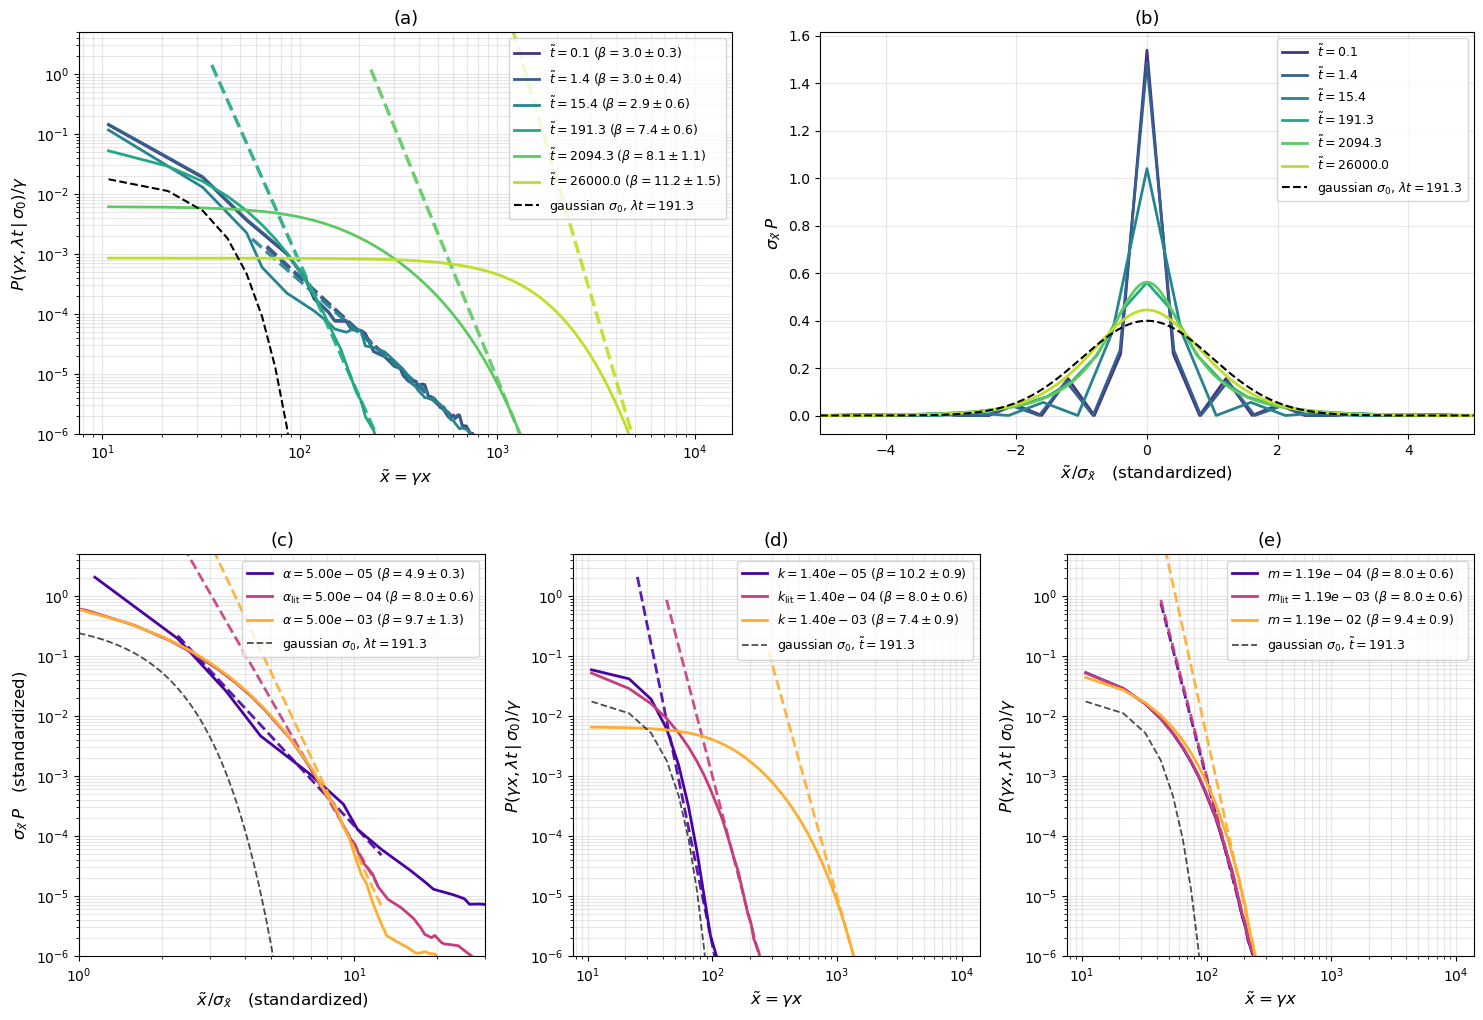

In [ ]:
# This cell adds a centered in zero, non-logarithmic P profile plot, together with the rest of the plots. It reuses all the previous cell code.
fig = plt.figure(figsize=(18, 12))
gs  = GridSpec(2, 6, figure=fig, hspace=0.30, wspace=0.55)
ax_a = fig.add_subplot(gs[0, 0:3])   # (a) tails
ax_b = fig.add_subplot(gs[0, 3:6])   # (b) bells
ax_c = fig.add_subplot(gs[1, 0:2])   # (c) rev_str
ax_d = fig.add_subplot(gs[1, 2:4])   # (d) noise
ax_e = fig.add_subplot(gs[1, 4:6])   # (e) mean

# Despite using previous code, the plots have to be re-run:
# pannel (a)
ax = ax_a
colors = plt.cm.viridis(np.linspace(0.15, 0.9, len(t_indices)))
x_pos_mask = x_tilde > 0
for k, t_idx in enumerate(t_indices):
    P = P_tilde[x_pos_mask, t_idx].copy()
    P /= trapezoid(P, x_pos)
    mean_x = trapezoid(x_pos * P, x_pos)
    var_x  = trapezoid((x_pos - mean_x) ** 2 * P, x_pos)
    if k == len(t_indices) // 2:
        var_for_ref = var_x
    nz = P > 1e-12
    xx, pp = x_pos[nz], P[nz]
    logP_smooth = savgol_filter(np.log(pp), window_length=15, polyorder=3)
    if k < FIT_N_CURVES:
        std_x = np.sqrt(var_x)
        fit_mask = (xx >= 5 * std_x) & (xx <= 15.0 * std_x)
        if fit_mask.sum() >= 3:
            slope = np.polyfit(np.log(xx[fit_mask]), logP_smooth[fit_mask], 1)[0]
            beta = -slope
            err = beta_with_error(xx, logP_smooth, var_x)
            if err is not None:
                beta_err, _, _, _ = err
                lbl = fr'$\tilde t={times[k]:.1f}$ ($\beta={beta:.1f}\pm{beta_err:.1f}$)'
            else:
                lbl = fr'$\tilde t={times[k]:.1f}$ ($\beta\approx{beta:.2f}$)'
            x_line = np.array([xx[fit_mask][0] / 3, xx[fit_mask][-1]])
            i_mid = fit_mask.sum() // 2
            anchor_x = xx[fit_mask][i_mid]
            anchor_y = np.exp(logP_smooth[fit_mask][i_mid])
            y_line = anchor_y * (x_line / anchor_x) ** slope
            ax.loglog(x_line, y_line, color=colors[k], ls='--', lw=2.5, alpha=0.9)
        else:
            lbl = fr'$\tilde t={times[k]:.1f}$'
    else:
        lbl = fr'$\tilde t={times[k]:.1f}$ '
    ax.loglog(xx, np.exp(logP_smooth), color=colors[k], lw=2, label=lbl)

tau_ref = times[len(t_indices) // 2]
if model_f == 'heston':
    sigma2_stat = mean
elif model_f == 'expou':
    sigma2_stat = np.exp(2 * mean + noise**2 / rev_str)
else:
    sigma2_stat = mean**2 + noise**2 / (2 * rev_str)
sigma_stat = np.sqrt(sigma2_stat)

REF_MODE = 'sigma_0'
if REF_MODE == 'sigma_0':
    ref_std_tilde = np.sqrt(2.0 * tau_ref); ref_subscript = r'\sigma_0'
elif REF_MODE == 'sigma_stat':
    ref_std_tilde = np.sqrt(2.0 * tau_ref) * sigma_stat / sigma_0
    ref_subscript = r'\sigma_\infty' if model_f in ('ou', 'expou') else r'\sqrt{\theta}'

if model_h == 'gaussian':
    ref = norm.pdf(x_pos, loc=0, scale=ref_std_tilde)
    ref_label = label=fr'gaussian $\sigma_0$, $\lambda t={tau_focus:.1f}$'
elif model_h == 'laplace':
    ref = laplace.pdf(x_pos, loc=0, scale=ref_std_tilde / np.sqrt(2))
    ref_label = fr'laplace, const-vol $\,{ref_subscript}\,$ at $\tilde t={tau_ref:.1f}$'
ax.loglog(x_pos[ref > 1e-12], ref[ref > 1e-12], 'k--', lw=1.5, label=ref_label)
ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=12)
ax.set_ylabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=12)
ax.legend(fontsize=9, loc='upper right'); ax.grid(True, which='both', alpha=0.3)
ax.set_ylim([1e-6, 5]); ax.set_title(r'(a)', fontsize=13)

# Pannel (b). This is the new part adding the same time-frames P profiles than (a) 
ax = ax_b
for k, t_idx in enumerate(t_indices):
    P = P_tilde[:, t_idx].copy()                 # full x range (both signs)
    Z = trapezoid(P, x_tilde)
    if Z <= 0:
        continue
    P /= Z
    mu  = trapezoid(x_tilde * P, x_tilde)
    var = trapezoid((x_tilde - mu) ** 2 * P, x_tilde)
    sx  = np.sqrt(var)
    u   = (x_tilde - mu) / sx
    ax.plot(u, P * sx, color=colors[k], lw=2, label=fr'$\tilde t={times[k]:.1f}$')   # P*std keeps area = 1
uu = np.linspace(-5, 5, 400)
ax.plot(uu, norm.pdf(uu), 'k--', lw=1.5, label=fr'gaussian $\sigma_0$, $\lambda t={tau_focus:.1f}$')
ax.set_xlim(-5, 5)
ax.set_xlabel(r'$\tilde x / \sigma_{\tilde x}$   (standardized)', fontsize=12)
ax.set_ylabel(r'$\sigma_{\tilde x}\, P$', fontsize=12)
ax.legend(fontsize=9, loc='upper right'); ax.grid(True, alpha=0.3)
ax.set_title(r'(b)', fontsize=13)

# Pannels (c)-(e) re-used from the previous code
if model_f == 'ou' or model_f == 'expou':
    sweep_specs = [(ax_c, 'rev_str', r'\alpha', 'c', True),
                   (ax_d, 'noise',   r'k',      'd', False),
                   (ax_e, 'mean',    r'm',      'e', False)]
elif model_f == 'heston':
    sweep_specs = [(ax_c, 'rev_str', r'\kappa', 'c', True),
                   (ax_d, 'noise',   r'\delta', 'd', False),
                   (ax_e, 'mean',    r'\theta', 'e', False)]
for ax, pname, psym, tag, standardize in sweep_specs:
    values = [base[pname] * f for f in (REVSTR_FACTORS if pname == 'rev_str' else SWEEP_FACTORS)]
    scolors = plt.cm.plasma(np.linspace(0.12, 0.82, len(values)))
    for c, val in enumerate(values):
        is_base = abs(val - base[pname]) <= 1e-9 * max(1.0, abs(base[pname]))
        if is_base and _prof_b is not None:
            prof = _prof_b
        else:
            p = dict(base); p[pname] = val
            xt, tr, Pt = compute_P_tilde(p['rev_str'], p['mean'], p['noise'],
                                         t_max=BASE_TMAX, N_omega=BASE_NOMEGA, n_grid=BASE_NGRID,
                                         x_max_target=BASE_XMAX, Nmax_cap=NMAX_CAP)
            j = int(np.argmin(np.abs(tr - tau_focus)))
            prof = tail_profile(Pt[:, j], xt)
        if prof is None:
            continue
        xx, logP_smooth, var_x = prof
        std_x = np.sqrt(var_x)
        sc = std_x if standardize else 1.0
        psym_c = fr'{psym}_{{\mathrm{{lit}}}}' if is_base else psym
        lbl = fr'${psym_c}={val:.2e}$'
        fit = powerlaw_fit(xx, logP_smooth, var_x, lo=6, hi=13)
        if fit is not None:
            beta, slope, x_line, y_line = fit
            err = beta_with_error(xx, logP_smooth, var_x)
            if err is not None:
                beta_err, b_lo, b_hi, _ = err
                lbl = fr'${psym_c}={val:.2e}$ ($\beta={beta:.1f}\pm{beta_err:.1f}$)'
            else:
                lbl = fr'${psym_c}={val:.2e}$ ($\beta\approx{beta:.2f}$)'
            ax.loglog(x_line / sc, y_line * sc, color=scolors[c], ls='--', lw=2.0, alpha=0.9)
        ax.loglog(xx / sc, np.exp(logP_smooth) * sc, color=scolors[c], lw=2, label=lbl)
    if standardize:
        u = np.logspace(0, np.log10(30), 200)
        ref_std = norm.pdf(u) if model_h == 'gaussian' else laplace.pdf(u, scale=1/np.sqrt(2))
        ax.loglog(u, ref_std, 'k--', lw=1.3, alpha=0.7, label=fr'gaussian $\sigma_0$, $\lambda t={tau_focus:.1f}$')
        ax.set_xlim([1, 30])
        ax.set_xlabel(r'$\tilde x / \sigma_{\tilde x}$   (standardized)', fontsize=12)
        ax.set_ylabel(r'$\sigma_{\tilde x}\, P$   (standardized)', fontsize=12)
    else:
        ax.loglog(x_pos[_ref_sweep > 1e-12], _ref_sweep[_ref_sweep > 1e-12],
                  'k--', lw=1.3, alpha=0.7, label=fr'gaussian $\sigma_0$, $\tilde t={tau_focus:.1f}$')
        ax.set_xlabel(r'$\tilde x = \gamma x$', fontsize=12)
        ax.set_ylabel(r'$P(\gamma x, \lambda t \,|\, \sigma_0)/\gamma$', fontsize=12)
    ax.set_title(fr'({tag})', fontsize=13)
    ax.legend(fontsize=9, loc='upper right'); ax.grid(True, which='both', alpha=0.3)
    ax.set_ylim([1e-6, 5])

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig(f'P_tails_panels_bells_f({model_f})_h({model_h}).png', dpi=200, bbox_inches='tight')
plt.show()